In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from Log_Extractor import LogExtractor
import os

### 어떤 펌프에 대해서?

In [2]:
# ==========================================
# ⚙️ 1. 설정 및 매개변수 (여기만 바꾸면 14개 펌프 무한 확장 가능!)
# ==========================================
PUMP_ID = 'P1' # 나중에 P2, P3 등으로 변경
TANK_ID = 'P1' # 나중에 T2, T3 등으로 변경
ROBOT_ID = 'RB1' # 나중에 R2, R3 등으로 변경
MODEL_SAVE_DIR = './models' # 모델과 스케일러를 저장할 폴더
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

In [ ]:
def prepare_pump_features(raw_df, pump_id, tank_id, robot_id):
    """
    [최종본] 모든 시계열 상태(Prev_SV 포함)를 연속된 시간선 위에서 먼저 계산하고,
    마지막에 가동(BuildUp==1) 구간만 추출합니다.
    """
    df = raw_df.ffill().fillna(0).copy()
    df_reset = df.reset_index() 
    
    tag_SV = f'g_s_SV_{pump_id}'
    tag_Ana = f'Ana_Out_{pump_id}'
    tag_PT = f'Scale_Out___PT_{pump_id}'
    tag_FT = f'Scale_Out___FT_{pump_id}'
    tag_Temp = f'TK_Temp_PV_{tank_id}'
    tag_BuildUp = f'Pump_BuildUp_{pump_id}' 
    tag_Wagon = f'{robot_id}_Robot_Num'

    # ==========================================
    # ✂️ 1. 블록(Block) ID 부여 (전체 연속 시간 기준)
    # ==========================================
    # 쉬는 시간(BuildUp=0)과 가동 시간(BuildUp=1)이 모두 고유한 블록 ID를 가집니다.
    df_reset['Wagon_Changed'] = df_reset[tag_Wagon].diff() != 0
    df_reset['BuildUp_Changed'] = df_reset[tag_BuildUp].diff() != 0
    df_reset['Wagon_Block_ID'] = (df_reset['Wagon_Changed'] | df_reset['BuildUp_Changed']).cumsum()

    # ==========================================
    # 🌍 2. 연속 시계열 파생 변수 생성 (자르기 전!)
    # ==========================================
    # [Prev_SV 연속 계산 로직]
    # 가동 구간(BuildUp==1)인 블록들의 최대 SV만 모아서 구함
    shot_sv_max = df_reset[df_reset[tag_BuildUp] == 1].groupby('Wagon_Block_ID')[tag_SV].max()
    
    # 1칸 당겨서 '이전 가동 샷의 SV' 생성
    prev_sv_map = shot_sv_max.shift(1).fillna(0)
    
    # 전체 데이터에 매핑 (실시간 전처리기에서 self.prev_sv를 들고 있는 것과 동일한 효과)
    df_reset['Prev_SV'] = df_reset['Wagon_Block_ID'].map(prev_sv_map)
    # 비가동 구간은 NaN이 되므로, 바로 이전 가동 샷의 값을 그대로 끌고 옴 (Forward Fill)
    df_reset['Prev_SV'] = df_reset['Prev_SV'].ffill().fillna(0)
    
    # 차이 계산
    df_reset['Prev_SV_Diff'] = df_reset[tag_SV] - df_reset['Prev_SV']

    # 나머지 연속 차분 변수들
    df_reset['Instant_SV_Diff'] = df_reset[tag_SV].diff().fillna(0)
    df_reset['Phase_Transition'] = np.where(df_reset['Instant_SV_Diff'] != 0, 1.0, 0.0)
    df_reset['Rolling_PT_Max_3'] = df_reset[tag_PT].rolling(window=3, min_periods=1).max()
    df_reset['Rolling_PT_Diff_3'] = df_reset[tag_PT].diff(periods=2).fillna(0)

    # ==========================================
    # 🎯 3. 진짜 가동 샷 추출 (BuildUp == 1)
    # ==========================================
    # 이미 과거의 상태값(Rolling, Prev_SV 등)은 전부 파생변수에 안전하게 담겨있습니다!
    df_shots = df_reset[df_reset[tag_BuildUp] == 1].copy()

    # ==========================================
    # 🔄 4. 샷(Shot) 내부 전용 피처 (인덱스 & 누적합)
    # ==========================================
    model_df = df_shots.copy()
    
    # 샷 안에서 얼마나 진행되었는지는 잘라낸 이후에 계산해야 0부터 시작함
    model_df['Tick_Index'] = model_df.groupby('Wagon_Block_ID').cumcount()
    model_df['Phase_Start'] = np.where(model_df['Tick_Index'] < 2, 1.0, 0.0)
    model_df['Phase_Steady'] = np.where(model_df['Tick_Index'] >= 2, 1.0, 0.0)

    # 누적 오차도 샷 내부에서만 쌓아야 함
    model_df['Instant_FT_Error'] = model_df[tag_SV] - model_df[tag_FT]
    model_df['Instant_FT_Error_Rate'] = np.where(
        model_df[tag_SV] > 0, 
        (model_df['Instant_FT_Error'] / model_df[tag_SV]) * 100, 
        0
    )
    model_df['Cum_FT_Error'] = model_df.groupby('Wagon_Block_ID')['Instant_FT_Error'].cumsum()

    # ==========================================
    # 🧹 5. 최종 컬럼 정리
    # ==========================================
    feature_cols = [
        tag_SV, 'Prev_SV', 'Prev_SV_Diff', 
        tag_Ana, tag_Temp,                
        tag_PT, 'Rolling_PT_Max_3', 'Rolling_PT_Diff_3', 
        tag_FT, 'Instant_FT_Error_Rate', 'Cum_FT_Error',  
        'Phase_Start', 'Phase_Steady', 'Phase_Transition'             
    ]
    
    model_df = model_df.fillna(0)
    
    return model_df[feature_cols], feature_cols

print("✅ 동적 피처 생성 함수 완료! (Prev_SV 연속 상태 반영)")

✅ 동적 피처 생성 함수 준비 완료! (하드 트리거 기반)


## 받아오는것은 직접해라.

In [4]:
# 한글 폰트 설정
plt.rc('font', family='AppleGothic') 
plt.rcParams['axes.unicode_minus'] = False

# 1. 추출기 가동 (어제 하루치 데이터만 가져오기)
# extractor는 이미 위에서 선언했다고 가정합니다.
target_tags = [
    f'Pump_BuildUp_{PUMP_ID}' , f'{ROBOT_ID}_Robot_Num', 
    f'g_s_SV_{PUMP_ID}', f'Ana_Out_{PUMP_ID}', 
    f'Scale_Out___PT_{PUMP_ID}', f'Scale_Out___FT_{PUMP_ID}', 
    f'TK_Temp_PV_{TANK_ID}', f'TK_Level_PV_{TANK_ID}'
]
extractor = LogExtractor()

🔌 [Extractor] InfluxDB 분석용 추출기 연결 완료!


# 데이터 불러오기

In [5]:
raw_df = extractor.get_data(start_time="2026-04-13T01:00:00Z", end_time="2026-04-17T15:00:00Z", target_tags=target_tags)
train_df, feature_cols = prepare_pump_features(raw_df, PUMP_ID, TANK_ID, ROBOT_ID)

🚀 전체 구간 데이터 추출 시작: 2026-04-13T01:00:00+00:00 ~ 2026-04-17T15:00:00+00:00
📦 [Chunk] 2026-04-13T01:00:00Z ~ 2026-04-13T07:00:00Z 요청 중...
📦 [Chunk] 2026-04-13T07:00:00Z ~ 2026-04-13T13:00:00Z 요청 중...
📦 [Chunk] 2026-04-13T13:00:00Z ~ 2026-04-13T19:00:00Z 요청 중...
📦 [Chunk] 2026-04-13T19:00:00Z ~ 2026-04-14T01:00:00Z 요청 중...
📦 [Chunk] 2026-04-14T01:00:00Z ~ 2026-04-14T07:00:00Z 요청 중...
📦 [Chunk] 2026-04-14T07:00:00Z ~ 2026-04-14T13:00:00Z 요청 중...
📦 [Chunk] 2026-04-14T13:00:00Z ~ 2026-04-14T19:00:00Z 요청 중...
📦 [Chunk] 2026-04-14T19:00:00Z ~ 2026-04-15T01:00:00Z 요청 중...
📦 [Chunk] 2026-04-15T01:00:00Z ~ 2026-04-15T07:00:00Z 요청 중...
📦 [Chunk] 2026-04-15T07:00:00Z ~ 2026-04-15T13:00:00Z 요청 중...
📦 [Chunk] 2026-04-15T13:00:00Z ~ 2026-04-15T19:00:00Z 요청 중...
📦 [Chunk] 2026-04-15T19:00:00Z ~ 2026-04-16T01:00:00Z 요청 중...
📦 [Chunk] 2026-04-16T01:00:00Z ~ 2026-04-16T07:00:00Z 요청 중...
📦 [Chunk] 2026-04-16T07:00:00Z ~ 2026-04-16T13:00:00Z 요청 중...
📦 [Chunk] 2026-04-16T13:00:00Z ~ 2026-04-16T19:00:00Z 요청 중.

In [6]:
rrr_df = extractor.get_data(start_time="2026-04-18T01:00:00Z", end_time="2026-04-18T09:00:00Z", target_tags=target_tags)
valid_df, _ = prepare_pump_features(rrr_df, PUMP_ID, TANK_ID, ROBOT_ID)

🚀 전체 구간 데이터 추출 시작: 2026-04-18T01:00:00+00:00 ~ 2026-04-18T09:00:00+00:00
📦 [Chunk] 2026-04-18T01:00:00Z ~ 2026-04-18T07:00:00Z 요청 중...
📦 [Chunk] 2026-04-18T07:00:00Z ~ 2026-04-18T09:00:00Z 요청 중...
✅ 전체 데이터 통합 완료! 총 7970행 확보.


# 데이터 짜르기

# Feature Engineering

# 표준화 작업과 모델 준비

In [7]:
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from Pump_AE import PumpAutoencoder
import joblib

In [8]:
# ==========================================
# ⚖️ 4. 스케일링 및 스케일러 저장 (매우 중요!)
# ==========================================
scaler = StandardScaler()

# *중요: 스케일러는 무조건 Train 데이터로만 fit 해야 합니다! (데이터 누수 방지)
X_train_scaled = scaler.fit_transform(train_df)
X_valid_scaled = scaler.transform(valid_df) # Valid는 transform만!

# 💾 배포용 스케일러 저장 (나중에 실시간 추론 스크립트에서 불러옵니다)
scaler_path = f"{MODEL_SAVE_DIR}/scaler_{PUMP_ID}.pkl"
joblib.dump(scaler, scaler_path)
print(f"💾 스케일러 저장 완료: {scaler_path}")

# 텐서 및 데이터로더 변환
train_tensor = torch.FloatTensor(X_train_scaled)
valid_tensor = torch.FloatTensor(X_valid_scaled)

train_loader = DataLoader(TensorDataset(train_tensor, train_tensor), batch_size=64, shuffle=True)
valid_loader = DataLoader(TensorDataset(valid_tensor, valid_tensor), batch_size=64, shuffle=False)

💾 스케일러 저장 완료: ./models/scaler_P1.pkl


In [9]:
# 피처 개수(11개)만큼 input_dim 설정
input_dim = len(feature_cols)
model = PumpAutoencoder(input_dim)

# 손실 함수(오차 계산)와 최적화 도구(학습 알고리즘) 설정
criterion = nn.MSELoss() # 평균 제곱 오차
optimizer = optim.Adam(model.parameters(), lr=0.005)

print(model)

PumpAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=14, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=4, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=14, bias=True)
  )
)


# 학습시작

In [10]:
# ==========================================
# 🤖 5. 모델 정의 및 학습 (Early Stopping 뼈대)
# ==========================================
input_dim = len(feature_cols)
model = PumpAutoencoder(input_dim) # (이전에 정의한 클래스 사용)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)

epochs = 200 # epoch을 넉넉하게 줍니다.
best_val_loss = float('inf')
model_path = f"{MODEL_SAVE_DIR}/autoencoder_{PUMP_ID}.pth"

print(f"\n🏃‍♂️ {PUMP_ID} 펌프 모델 학습 시작...")
for epoch in range(epochs):
    # --- Train Phase ---
    model.train()
    total_train_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
    
    avg_train_loss = total_train_loss / len(train_loader)
    
    # --- Validation Phase ---
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch_x, batch_y in valid_loader:
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            total_val_loss += loss.item()
            
    avg_val_loss = total_val_loss / len(valid_loader)
    
    # 최고 성능 갱신 시 모델 저장!
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        # 💾 모델 가중치 저장
        torch.save(model.state_dict(), model_path)
        saved_flag = "⭐ (Best Model Saved!)"
    else:
        saved_flag = ""
        
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:03d}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} {saved_flag}")

print(f"\n✅ 학습 완료! 최적의 모델이 저장되었습니다: {model_path}")


🏃‍♂️ P1 펌프 모델 학습 시작...
Epoch [001/200] | Train Loss: 0.3094 | Val Loss: 0.2587 ⭐ (Best Model Saved!)
Epoch [010/200] | Train Loss: 0.1092 | Val Loss: 0.1037 ⭐ (Best Model Saved!)
Epoch [020/200] | Train Loss: 0.1065 | Val Loss: 0.0916 
Epoch [030/200] | Train Loss: 0.1060 | Val Loss: 0.0926 
Epoch [040/200] | Train Loss: 0.1058 | Val Loss: 0.0920 
Epoch [050/200] | Train Loss: 0.1058 | Val Loss: 0.0937 
Epoch [060/200] | Train Loss: 0.1057 | Val Loss: 0.0924 
Epoch [070/200] | Train Loss: 0.1057 | Val Loss: 0.0921 
Epoch [080/200] | Train Loss: 0.1056 | Val Loss: 0.0911 
Epoch [090/200] | Train Loss: 0.1056 | Val Loss: 0.0927 
Epoch [100/200] | Train Loss: 0.1056 | Val Loss: 0.0929 
Epoch [110/200] | Train Loss: 0.1058 | Val Loss: 0.0916 
Epoch [120/200] | Train Loss: 0.1057 | Val Loss: 0.0927 
Epoch [130/200] | Train Loss: 0.1056 | Val Loss: 0.0923 
Epoch [140/200] | Train Loss: 0.1055 | Val Loss: 0.0921 
Epoch [150/200] | Train Loss: 0.1055 | Val Loss: 0.0922 
Epoch [160/200] | Trai

# 모델 테스트

In [ ]:
feature_cols = [
                    f'g_s_SV_{PUMP_ID}', 'Prev_SV', 'Prev_SV_Diff', 
                    f'Ana_Out_{PUMP_ID}', f'TK_Temp_PV_{TANK_ID}',               
                    f'Scale_Out___PT_{PUMP_ID}', 'Rolling_PT_Max_3', 'Rolling_PT_Diff_3', 
                    f'Scale_Out___FT_{PUMP_ID}', 'Instant_FT_Error_Rate', 'Cum_FT_Error',  
                    'Phase_Start', 'Phase_Steady', 'Phase_Transition'             
                ]

In [12]:
import joblib
import torch
from Pump_AE import PumpAutoencoder

MODEL_SAVE_DIR = './models' # 모델과 스케일러를 저장할 폴더
PUMP_ID = 'P1' # 나중에 P2, P3 등으로 변경

model = PumpAutoencoder(input_dim=len(feature_cols))
model.load_state_dict(torch.load(f'{MODEL_SAVE_DIR}/autoencoder_{PUMP_ID}.pth', weights_only=True))
model.eval() # 추론 모드

scaler = joblib.load(f'{MODEL_SAVE_DIR}/scaler_{PUMP_ID}.pkl')


In [13]:
from Fast_Log_Ext import Fast_LogExtractor

fext = Fast_LogExtractor()
test_df = fext.get_data(start_time="2026-04-18T01:00:00Z", end_time="2026-04-18T15:00:00Z", target_tags=target_tags)

🔌 [Extractor] InfluxDB 분석용 추출기 연결 완료!
🚀 추출 시작: 2026-04-18 01:00:00 ~ 2026-04-18 15:00:00 (KST 기준)
📦 [Chunk 요청] 2026-04-18T01:00:00Z ~ 2026-04-18T07:00:00Z ... 성공 (8775행)
📦 [Chunk 요청] 2026-04-18T07:00:00Z ~ 2026-04-18T13:00:00Z ... 데이터 없음
📦 [Chunk 요청] 2026-04-18T13:00:00Z ~ 2026-04-18T15:00:00Z ... 데이터 없음
🔄 데이터 통합 및 KST 변환 중...
✅ 최종 추출 완료! 총 8775행, 8개 컬럼 확보.


In [14]:
from Pump_Preprocess import RealTimePreprocessor
# 1. 전처리기 객체 생성 (학습할 때 만들었던 scaler와 feature_cols를 넣어줍니다)
preprocessor = RealTimePreprocessor(
    scaler=scaler, 
    feature_cols=feature_cols, 
    pump_id=PUMP_ID, 
    tank_id=TANK_ID, 
    robot_id=ROBOT_ID
)

# 결과를 담을 빈 리스트
inference_results = []
# 2. 실시간 시뮬레이션
# raw_df는 추출기에서 가져온 아무 가공도 안 된 쌩(Raw) 데이터프레임입니다.
print("📡 실시간 데이터 스트리밍 시작...")

for i in range(len(test_df)):
    raw_tick = test_df.iloc[i] # 진짜 딱 1줄씩 가져옴
    
    # [노이즈 필터링] 안 쏘거나 정지 중인 데이터는 스킵 (실시간 판단)
    if raw_tick[f'Pump_BuildUp_{PUMP_ID}'] != 1:
        continue
        
    # ------------------------------------------------
    # 🎩 마법의 전처리기 통과!
    # ------------------------------------------------
    tensor_data, df_processed, meta_info = preprocessor.process_raw_tick(raw_tick)
    
    # ------------------------------------------------
    # 🤖 모델 추론
    # ------------------------------------------------
    model.eval()
    with torch.no_grad():
        reconstructed = model(tensor_data)
        mse_loss = torch.mean((tensor_data - reconstructed) ** 2).item()
        feature_errors = torch.abs(tensor_data - reconstructed).numpy()[0]
    
    # ★ 결과 저장 (그래프를 그리기 위해 핵심 데이터만 모읍니다)
    inference_results.append({
        'Time': raw_tick.name, # 이 부분이 꼭 있어야 X축으로 쓸 수 있습니다!
        'Wagon_Num': meta_info['Wagon_Num'],
        'Tick_Index': meta_info['Tick_Index'],
        'Loss': mse_loss,
        'Target_SV': df_processed['g_s_SV_P1'].values[0],
        'Actual_FT': df_processed['Scale_Out___FT_P1'].values[0],
        'Actual_PT': df_processed['Scale_Out___PT_P1'].values[0]
    })
    
    # 리스트를 데이터프레임으로 변환
    results_df = pd.DataFrame(inference_results)
    print(f"✅ 총 {len(results_df)}틱의 추론 결과 수집 완료!")
    
    # 테스트를 위해 일정량 수집 후 종료 (필요시 조절)
    if len(inference_results) >= 50000:
        break

# 결과 확인
results_df = pd.DataFrame(inference_results)
print(f"✅ 총 {len(results_df)}틱의 추론 완료!")
print(results_df.head(10))

📡 실시간 데이터 스트리밍 시작...
✅ 총 1틱의 추론 결과 수집 완료!
✅ 총 2틱의 추론 결과 수집 완료!
✅ 총 3틱의 추론 결과 수집 완료!
✅ 총 4틱의 추론 결과 수집 완료!
✅ 총 5틱의 추론 결과 수집 완료!
✅ 총 6틱의 추론 결과 수집 완료!
✅ 총 7틱의 추론 결과 수집 완료!
✅ 총 8틱의 추론 결과 수집 완료!
✅ 총 9틱의 추론 결과 수집 완료!
✅ 총 10틱의 추론 결과 수집 완료!
✅ 총 11틱의 추론 결과 수집 완료!
✅ 총 12틱의 추론 결과 수집 완료!
✅ 총 13틱의 추론 결과 수집 완료!
✅ 총 14틱의 추론 결과 수집 완료!
✅ 총 15틱의 추론 결과 수집 완료!
✅ 총 16틱의 추론 결과 수집 완료!
✅ 총 17틱의 추론 결과 수집 완료!
✅ 총 18틱의 추론 결과 수집 완료!
✅ 총 19틱의 추론 결과 수집 완료!
✅ 총 20틱의 추론 결과 수집 완료!
✅ 총 21틱의 추론 결과 수집 완료!
✅ 총 22틱의 추론 결과 수집 완료!
✅ 총 23틱의 추론 결과 수집 완료!
✅ 총 24틱의 추론 결과 수집 완료!
✅ 총 25틱의 추론 결과 수집 완료!
✅ 총 26틱의 추론 결과 수집 완료!
✅ 총 27틱의 추론 결과 수집 완료!
✅ 총 28틱의 추론 결과 수집 완료!
✅ 총 29틱의 추론 결과 수집 완료!
✅ 총 30틱의 추론 결과 수집 완료!
✅ 총 31틱의 추론 결과 수집 완료!
✅ 총 32틱의 추론 결과 수집 완료!
✅ 총 33틱의 추론 결과 수집 완료!
✅ 총 34틱의 추론 결과 수집 완료!
✅ 총 35틱의 추론 결과 수집 완료!
✅ 총 36틱의 추론 결과 수집 완료!
✅ 총 37틱의 추론 결과 수집 완료!
✅ 총 38틱의 추론 결과 수집 완료!
✅ 총 39틱의 추론 결과 수집 완료!
✅ 총 40틱의 추론 결과 수집 완료!
✅ 총 41틱의 추론 결과 수집 완료!
✅ 총 42틱의 추론 결과 수집 완료!
✅ 총 43틱의 추론 결과 수집 완료!
✅ 총 44틱의 추론 결과 수집 완료!
✅ 총 45틱의 추론 결과 수집 완료

In [17]:
from Detect_Anomaly import detect_anomaly, identify_culprit, extract_context_data
# 1. 설정값 세팅
THRESHOLD = 4  
LOOKBACK = 5     

realtime_buffer = [] 

print(f"🚀 [시스템 가동] 임계치 {THRESHOLD} 기반 실시간 감시 및 정밀 분석 시작...")
print("=" * 80)

anomaly_count = 0

for i in range(len(test_df)):
    raw_tick = test_df.iloc[i]
    
    # ⏱️ 핵심: 현재 데이터의 시간(Timestamp) 가져오기
    # 보통 InfluxDB에서 가져온 데이터프레임은 인덱스(name)가 시간입니다.
    current_time = raw_tick.name 
    
    # [필터링] 가동 중일 때만 분석
    # [필터링] 빌드업 신호가 있을 때만 분석 수행 (앞서 합의한 규칙)
    if raw_tick[f'Pump_BuildUp_{PUMP_ID}'] != 1:
        continue
        
    # 1. 전처리 통과
    tensor_data, df_processed, meta_info = preprocessor.process_raw_tick(raw_tick)

    # [추가된 로직] 현재 샷이 '콜드 스타트'인지 확인
    is_cold_start = False
    
    # 현재 버퍼에 이전 샷 기록이 있고, 현재 틱이 샷의 극초반(예: 0~2틱)일 때만 검사
    if len(realtime_buffer) > 0 and meta_info['Tick_Index'] <= 2:
        last_shot_time = realtime_buffer[-1]['Time'].iloc[0]
        current_time = raw_tick.name
        
        # 직전 데이터와 현재 데이터의 시간 차이가 3분(180초) 이상이면 콜드 스타트로 간주
        time_diff = (current_time - last_shot_time).total_seconds()
        if time_diff > 10:
            is_cold_start = True
    
    # 분석을 위해 버퍼에 저장할 때 시간 정보도 같이 넣습니다.
    current_record = df_processed.copy()
    current_record['Time'] = current_time  # 시간 컬럼 추가!
    current_record['Wagon_Num'] = meta_info['Wagon_Num']
    current_record['Tick_Index'] = meta_info['Tick_Index']
    realtime_buffer.append(current_record)
    
    # 2. 실시간 이상 탐지
    mse_score, feature_errors = detect_anomaly(model, scaler, df_processed, feature_cols)
    
    # 3. 이상 발생 시 정밀 진단
    if mse_score > THRESHOLD:
        if is_cold_start:
            # 점수가 높아도 알람을 울리지 않고 넘어갑니다. (로그만 가볍게 남김)
            # print(f"🕒 [콜드 스타트 무시] 3분 이상 대기 후 첫 가동이라 알람을 생략합니다. (Time: {current_time})")
            continue
        anomaly_count += 1
        
        culprits = identify_culprit(feature_errors, feature_cols, top_k=3)
        
        buffer_df = pd.concat(realtime_buffer)
        context_df = extract_context_data(buffer_df, len(buffer_df)-1, lookback=LOOKBACK)
        
        # ------------------------------------------------
        # 📋 정밀 분석 리포트 출력 (시간 추가됨!)
        # ------------------------------------------------
        print(f"🚨 [ANOMALY DETECTED #{anomaly_count}]")
        # 보기 좋게 시간을 문자열 형식(YYYY-MM-DD HH:MM:SS)으로 출력
        formatted_time = current_time.strftime('%Y-%m-%d %H:%M:%S') if hasattr(current_time, 'strftime') else current_time
        print(f"⏰ 발생 시간: {formatted_time}")
        print(f"📍 발생 위치: 대차 번호 {meta_info['Wagon_Num']} | 샷 내 위치: {meta_info['Tick_Index']} 틱")
        print(f"📈 이상 점수(MSE): {mse_score:.4f} (위험 수준)")
        
        print(f"🕵️‍♂️ 범인 색출 결과 (Top 3 기여도):")
        for idx, row in culprits.iterrows():
            print(f"   - [{row['Feature']}] : {row['Error_Contribution(%)']:.1f}% 지분")
            
        print(f"📦 상황(Context) 데이터 (최근 {len(context_df)}틱 흐름):")
        # 상황 데이터 출력할 때도 시간(Time)을 맨 앞에 보여줍니다.
        display_cols = ['Time', 'Tick_Index', 'g_s_SV_P1', 'Scale_Out___PT_P1', 'Scale_Out___FT_P1', 'Instant_FT_Error_Rate']
        print(context_df[display_cols].to_string(index=False))
        
        print("-" * 80)
        
        if anomaly_count >= 500: # 이번엔 5개까지 넉넉하게 뽑아봅시다
            print("💡 초기 분석을 위해 5개의 케이스만 추출했습니다. 루프를 종료합니다.")
            break

if anomaly_count == 0:
    print("✅ 현재 데이터 구간에서는 임계치를 넘는 이상 징후가 발견되지 않았습니다.")

🚀 [시스템 가동] 임계치 4 기반 실시간 감시 및 정밀 분석 시작...
🚨 [ANOMALY DETECTED #1]
⏰ 발생 시간: 2026-04-18 10:32:44
📍 발생 위치: 대차 번호 27.0 | 샷 내 위치: 1 틱
📈 이상 점수(MSE): 4.0309 (위험 수준)
🕵️‍♂️ 범인 색출 결과 (Top 3 기여도):
   - [Rolling_PT_Diff_3] : 38.4% 지분
   - [Cum_FT_Error] : 15.2% 지분
   - [Phase_Transition] : 11.3% 지분
📦 상황(Context) 데이터 (최근 5틱 흐름):
                      Time  Tick_Index  g_s_SV_P1  Scale_Out___PT_P1  Scale_Out___FT_P1  Instant_FT_Error_Rate
2026-04-18 10:32:36.195912           2     2540.0              117.0             2527.0               0.511811
2026-04-18 10:32:38.194108           3     2540.0              117.0             2527.0               0.511811
2026-04-18 10:32:40.451662           4     2540.0              116.0             2527.0               0.511811
2026-04-18 10:32:43.628600           0     2540.0               65.0             1519.0              40.196850
2026-04-18 10:32:44.762609           1     2540.0              114.0             1534.0              39.606299
-----------------

/var/folders/fj/zp006l253zsg23q736jqrh800000gn/T/ipykernel_6575/159098156.py:62: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) AppleGothic.
  plt.tight_layout()
/var/folders/fj/zp006l253zsg23q736jqrh800000gn/T/ipykernel_6575/159098156.py:62: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) AppleGothic.
  plt.tight_layout()
/Users/jeonjae/Desktop/KTA/DB_Log/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeonjae/Desktop/KTA/DB_Log/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


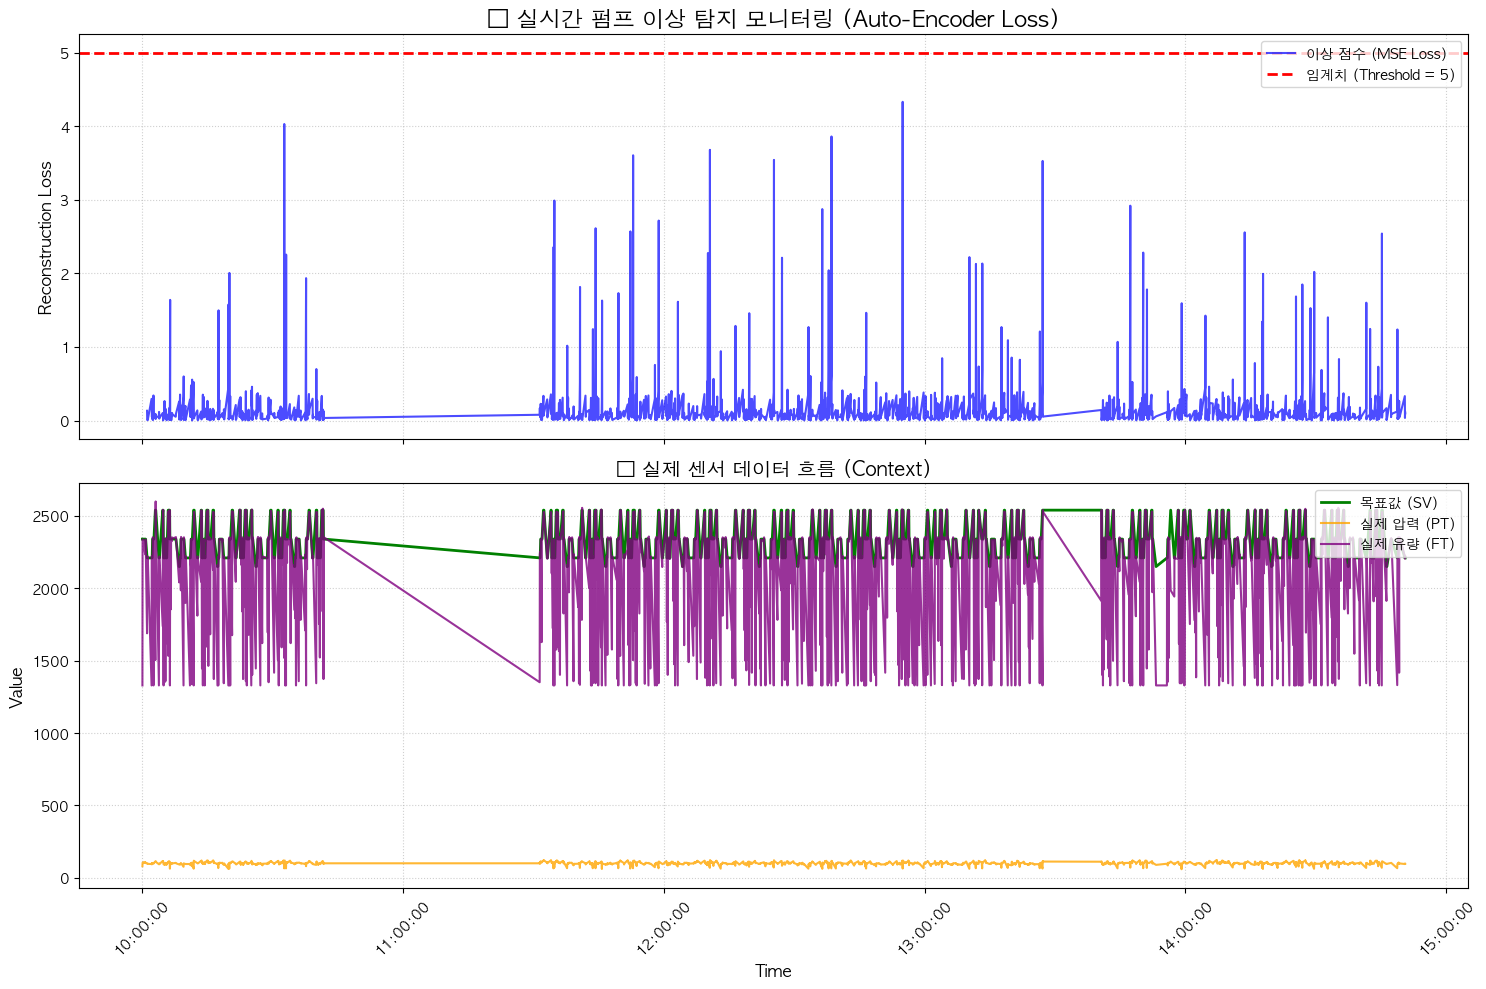

In [16]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# 한글 폰트 설정 (폰트 깨짐 방지 - 환경에 맞게 수정 필요)
plt.rcParams['font.family'] = 'AppleGothic' # Windows
# plt.rcParams['font.family'] = 'AppleGothic' # Mac
plt.rcParams['axes.unicode_minus'] = False

def plot_anomaly_results(results_df, threshold=0.5):
    """
    AE 이상 탐지 결과를 시각화합니다.
    Top: 시간(X축)에 따른 이상 점수(Loss)와 임계치(Threshold)
    Bottom: 시간(X축)에 따른 SV(목표 압력), PT(실제 압력), FT(유량) 변화
    """
    # Time 컬럼을 datetime 형식으로 변환 (인덱스가 아닌 경우 대비)
    if not pd.api.types.is_datetime64_any_dtype(results_df['Time']):
        results_df['Time'] = pd.to_datetime(results_df['Time'])
        
    # 이상치(Anomaly)만 따로 필터링
    anomalies = results_df[results_df['Loss'] > threshold]

    # 그래프 레이아웃 설정 (위아래 2칸)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

    # -----------------------------------------------------------
    # [Top 그래프] 이상 점수 (Reconstruction Loss) 모니터링
    # -----------------------------------------------------------
    ax1.plot(results_df['Time'], results_df['Loss'], color='blue', alpha=0.7, label='이상 점수 (MSE Loss)')
    ax1.axhline(y=threshold, color='red', linestyle='--', linewidth=2, label=f'임계치 (Threshold = {threshold})')
    
    # 임계치를 넘은 구간 빨간색 점으로 강조
    if not anomalies.empty:
        ax1.scatter(anomalies['Time'], anomalies['Loss'], color='red', s=50, zorder=5, label='Anomaly Detected')
        
    ax1.set_title("🚀 실시간 펌프 이상 탐지 모니터링 (Auto-Encoder Loss)", fontsize=16, fontweight='bold')
    ax1.set_ylabel("Reconstruction Loss", fontsize=12)
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend(loc='upper right')

    # -----------------------------------------------------------
    # [Bottom 그래프] 원본 시계열 데이터 흐름 (SV, PT, FT)
    # -----------------------------------------------------------
    ax2.plot(results_df['Time'], results_df['Target_SV'], color='green', linestyle='-', linewidth=2, label='목표값 (SV)')
    ax2.plot(results_df['Time'], results_df['Actual_PT'], color='orange', linestyle='-', alpha=0.8, label='실제 압력 (PT)')
    ax2.plot(results_df['Time'], results_df['Actual_FT'], color='purple', linestyle='-', alpha=0.8, label='실제 유량 (FT)')

    # 아래쪽 그래프에도 이상 구간을 연한 빨간색 세로 배경으로 표시
    for anomaly_time in anomalies['Time']:
        ax2.axvline(x=anomaly_time, color='red', alpha=0.2, linestyle='-')

    ax2.set_title("📈 실제 센서 데이터 흐름 (Context)", fontsize=14)
    ax2.set_xlabel("Time", fontsize=12)
    ax2.set_ylabel("Value", fontsize=12)
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.legend(loc='upper right')

    # X축 시간 포맷팅 (HH:MM:SS 형태로 깔끔하게)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

# 함수 실행!
plot_anomaly_results(results_df, threshold=THRESHOLD)